In [21]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

while Path().resolve().name != "QoraDFXM":
    os.chdir("..")

if "src/qoradfxm" not in sys.path:
    sys.path.append("src/qoradfxm")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

In [25]:
root: Path = Path(r"C:\WorkSpace\05_Resources\Data\QoraDFXM\ue_260617_QoraDFXM\dat")
file1: Path = root / "20260618/260618_shockwave_01_00001.h5"
file2: Path = root / "20260618/260618_shockwave_01_00002.h5"

with h5py.File(file1, "r") as hf1, h5py.File(file2, "r") as hf2:
    det = hf1["run/scan00001/det"]
    det_key = list(det.keys())[0]
    img1: np.ndarray = det[det_key]["data"][()].squeeze()
    det = hf2["run/scan00001/det"]
    det_key = list(det.keys())[0]
    img2: np.ndarray = det[det_key]["data"][()].squeeze()

    print("image shape:", img1.shape)
    print("image shape:", img2.shape)

image shape: (2048, 2048)
image shape: (2048, 2048)


C:\Users\user\AppData\Local\Temp\ipykernel_17472\1920762154.py:15: RuntimeWarning: invalid value encountered in log
  ax[1, 1].imshow(np.log(img2 - img1_scaled))


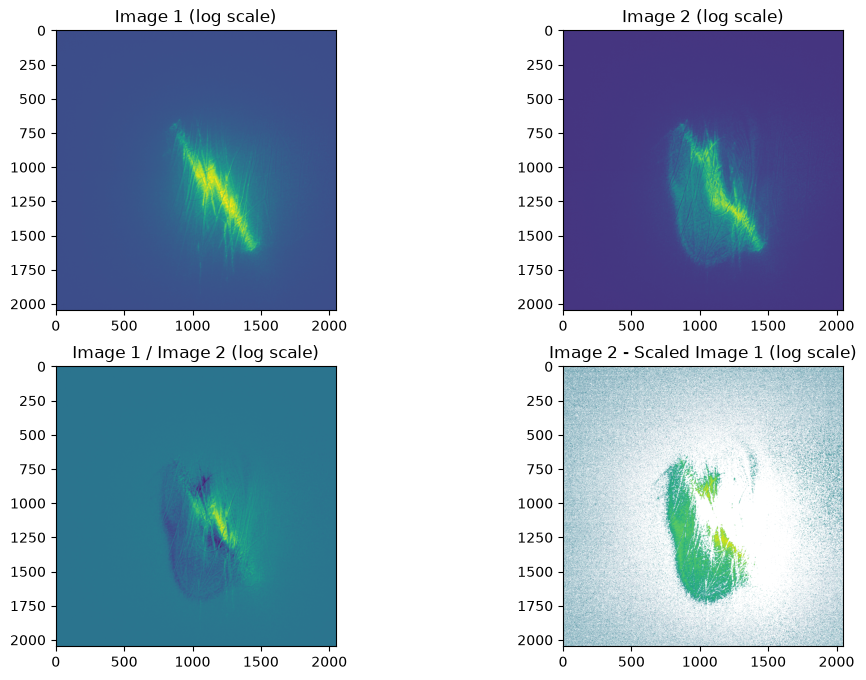

In [26]:
bg_zone_off: np.ndarray = img1[0:50, -50:-1]
bg_zone_on: np.ndarray = img2[0:50, -50:-1]
mean_bg_off: float = np.mean(bg_zone_off)
mean_bg_on: float = np.mean(bg_zone_on)

scale_factor: float = mean_bg_on / mean_bg_off
img1_scaled: np.ndarray = img1 * scale_factor
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].imshow(np.log(img1))
ax[0, 0].set_title("Image 1 (log scale)")
ax[0, 1].imshow(np.log(img2))
ax[0, 1].set_title("Image 2 (log scale)")
ax[1, 0].imshow(np.log(img1 / img2))
ax[1, 0].set_title("Image 1 / Image 2 (log scale)")
ax[1, 1].imshow(np.log(img2 - img1_scaled))
ax[1, 1].set_title("Image 2 - Scaled Image 1 (log scale)")
plt.show()

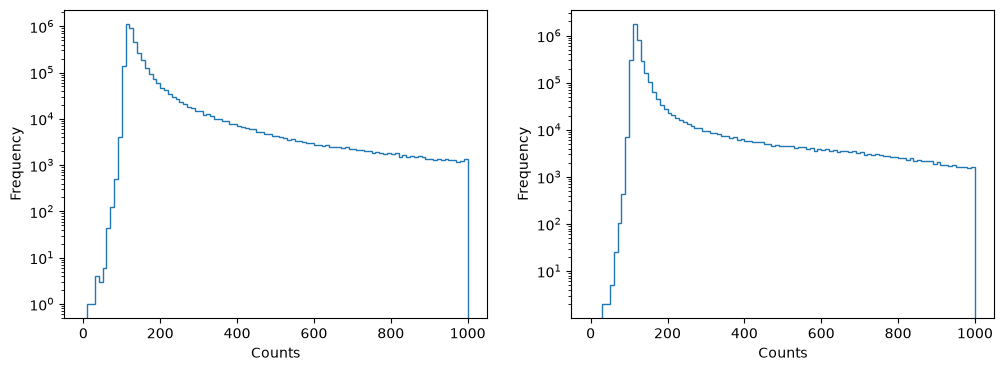

In [27]:
counts1, bin_edges1 = np.histogram(img1, bins=100, range=(0, 1000))
counts2, bin_edges2 = np.histogram(img2, bins=100, range=(0, 1000))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].stairs(counts1, bin_edges1)
ax[1].stairs(counts2, bin_edges2)
for a in ax:
    a.set_xlabel("Counts")
    a.set_ylabel("Frequency")
    a.set_yscale("log")
plt.show()

In [28]:
import cv2

# 이미지를 1/4로 줄여서 배경을 계산하므로 연산 속도가 수백 배 빨라집니다.
scale = 0.25
radius = 1000
img_small = cv2.resize(img2, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

# 반지름도 1/4 크기인 125로 축소
small_radius = int(radius * scale)
small_kernel_size = small_radius * 2 + 1
kernel_small = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, (small_kernel_size, small_kernel_size)
)

# 축소된 이미지에서 배경만 추출 (Morphology Open)
bg_small = cv2.morphologyEx(img_small, cv2.MORPH_OPEN, kernel_small)

# 배경을 다시 원본 크기로 확대
bg_large = cv2.resize(
    bg_small, (img1.shape[1], img1.shape[0]), interpolation=cv2.INTER_LINEAR
)

# 원본에서 배경 빼기
result = cv2.subtract(img1, bg_large)

C:\Users\user\AppData\Local\Temp\ipykernel_17472\4281531219.py:5: RuntimeWarning: divide by zero encountered in log1p
  ax[1].imshow(np.log1p(result))
C:\Users\user\AppData\Local\Temp\ipykernel_17472\4281531219.py:5: RuntimeWarning: invalid value encountered in log1p
  ax[1].imshow(np.log1p(result))


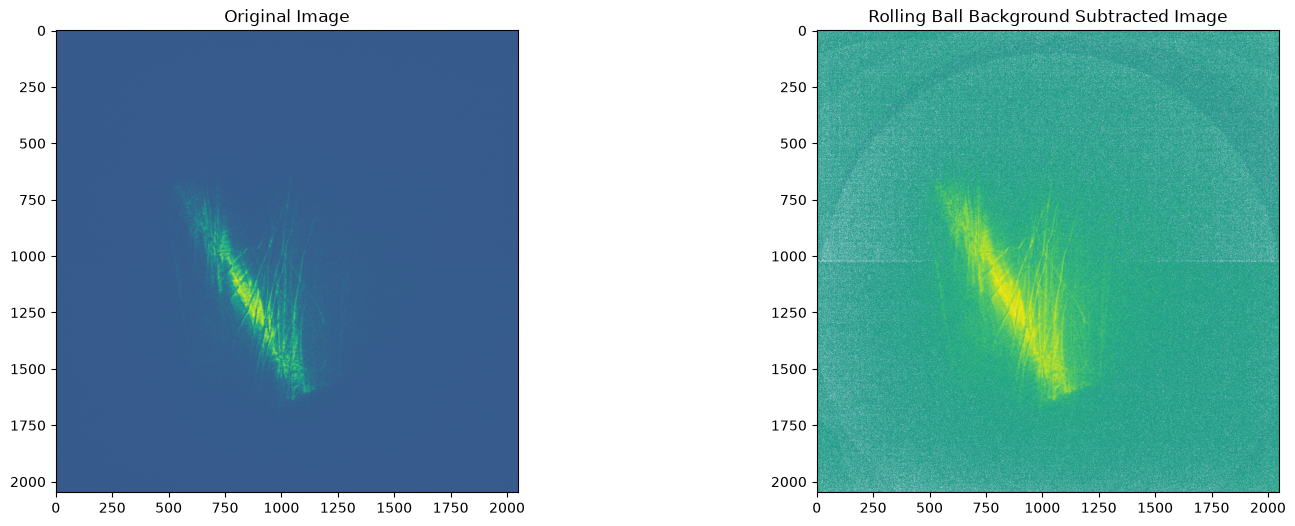

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.log1p(img1))
ax[0].set_title("Original Image")

ax[1].imshow(np.log1p(result))
ax[1].set_title("Rolling Ball Background Subtracted Image")
plt.show()

In [20]:
import cupy as cp
import numpy as np
from cupyx.scipy import ndimage


def gpu_rolling_ball_alternative(img_cpu: np.ndarray, radius: int = 150) -> np.ndarray:
    """
    CuPy(GPU)를 사용하여 scikit-image의 rolling_ball과 유사한
    배경 제거(White Top-Hat) 연산을 초고속으로 수행합니다.
    """
    # 1. CPU 데이터를 RTX 5070 VRAM 전송
    img_gpu = cp.array(img_cpu, dtype=cp.float32)

    # 2. 지정한 반경(radius) 크기의 원형(구조 요소) 커널 생성
    y, x = cp.ogrid[-radius : radius + 1, -radius : radius + 1]
    kernel = (x**2 + y**2 <= radius**2).astype(cp.uint8)

    # 3. GPU 가속 모폴로지 탑햇 연산 (배경 감산 자동 포함)
    # 완만한 저주파 배경을 날리고 고주파 신호만 남깁니다.
    result_gpu = ndimage.white_tophat(img_gpu, footprint=kernel)

    # 4. 결과를 다시 CPU(NumPy) 배열로 반환
    return cp.asnumpy(result_gpu)


result_gpu = gpu_rolling_ball_alternative(img2, radius=1000)

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.log1p(img2))
ax[0].set_title("Original Image")

ax[1].imshow(np.log1p(result_gpu))
ax[1].set_title("Rolling Ball Background Subtracted Image")
plt.show()

KeyboardInterrupt: 

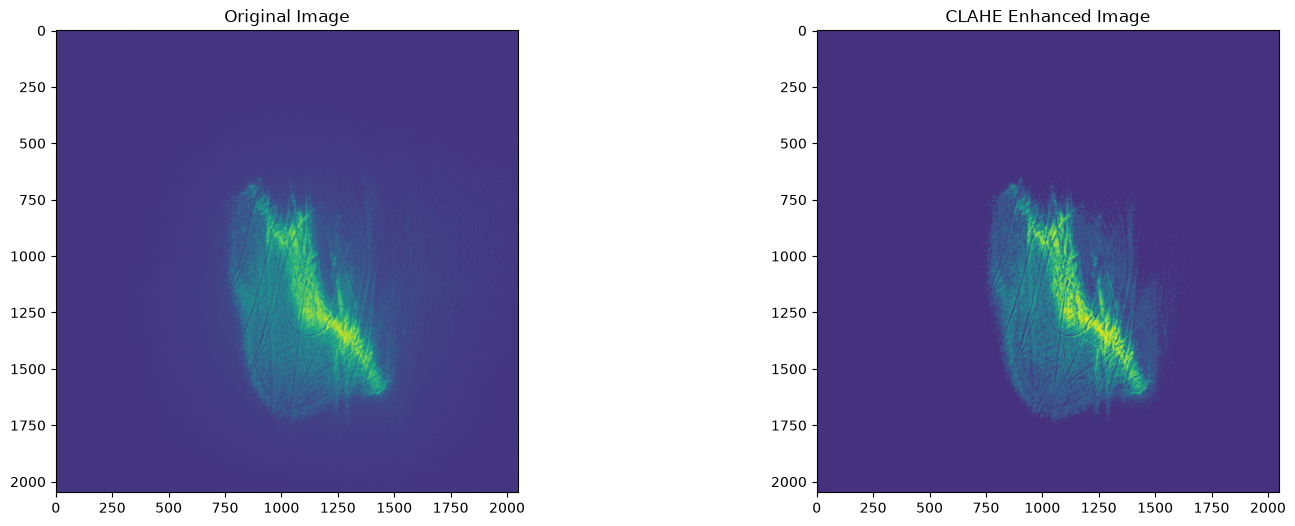

In [ ]:
# 1. CLAHE는 uint8(0~255) 데이터 타입에서 가장 잘 작동합니다.
# 만약 float64/32라면 0~255 스케일로 변환이 필요합니다.
if img2.dtype != np.uint8:
    # 0~1 사이로 정규화 후 255를 곱하는 예시
    img_normalized = ((img2 - img2.min()) / (img2.max() - img2.min()) * 255).astype(
        np.uint8
    )
else:
    img_normalized = img2.copy()

# 2. CLAHE 객체 생성
# clipLimit: 대비가 과도하게 튀는 것을 제한 (높을수록 대비가 강해짐)
# tileGridSize: 이미지를 쪼갤 격자 크기 (이미지 크기가 2000x2000이므로 32x32나 64x64 추천)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(64, 64))

# 3. 적용
img_flattened = clahe.apply(img_normalized)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.log1p(img2))
ax[0].set_title("Original Image")

ax[1].imshow(np.log1p(img_flattened))
ax[1].set_title("CLAHE Enhanced Image")
plt.show()

In [ ]:
import numpy as np

# 1. 히스토그램을 계산하여 가장 빈도수가 높은(가장 많은 픽셀이 가진) 밝기 값을 찾습니다.
counts, bins = np.histogram(img2, bins=256)
background_mode_value = bins[np.argmax(counts)]

# 2. 원본 이미지에서 이 배경 대표값을 빼줍니다.
# 배경값보다 어두운 곳이 음수가 되지 않도록 clip(0 또는 최소값) 처리를 해줍니다.
img_flattened = img2 - background_mode_value
img_flattened = np.clip(img_flattened, 0, None)  # 0 이하의 값은 다 0으로 평탄화

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.log1p(img2))
ax[0].set_title("Original Image")

ax[1].imshow(np.log1p(img_flattened))
ax[1].set_title("Background Subtracted Image")
plt.show()

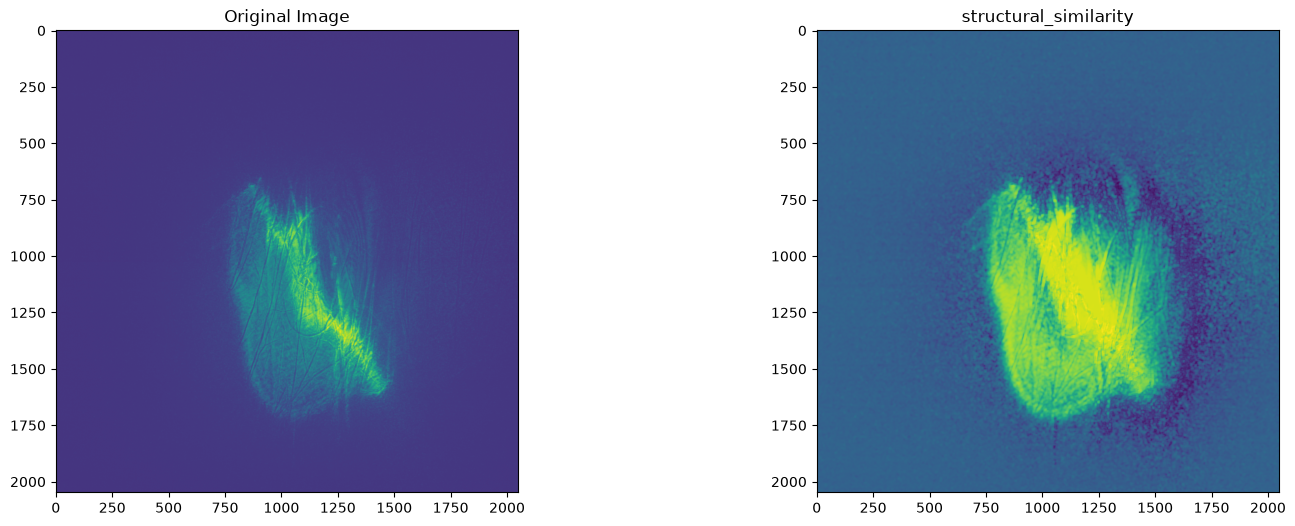

In [ ]:
from skimage.metrics import structural_similarity as ssim

# 1. 두 이미지의 데이터 타입을 float32로 변환
img1 = img1.astype(np.float32)
# 우측(맞은 후) 이미지는 배경이 약간 더 어두우므로 스케일을 정규화해야 합니다.
img2 = img2.astype(np.float32)

# 2. 이미지 정규화 (Min-Max 정규화를 통해 밝기 다이나믹 레인지를 0~1로 통일)
img1_norm = (img1 - img1.min()) / (img1.max() - img1.min())
img2_norm = (img2 - img2.min()) / (img2.max() - img2.min())

# 3. 정규화된 상태에서 빼기 연산 (변화된 구조만 도드라짐)
# 절댓값을 씌우면 양방향 변화(밝아진 곳, 어두워진 곳)를 모두 볼 수 있습니다.
diff = np.abs(img2_norm - img1_norm)
# win_size는 주변을 조사할 윈도우 크기입니다.
# data_range는 이미지의 데이터 범위 (0~1로 정규화했으므로 1.0)
# full=True로 설정하면 이미지 크기와 똑같은 유사도 맵(diff_map)을 반환합니다.
score, diff_map = ssim(img1_norm, img2_norm, win_size=11, data_range=1.0, full=True)

# diff_map은 1에 가까울수록 변하지 않은 곳, 0에 가까울수록 레이저에 의해 구조가 바뀐 곳입니다.
# 따라서 반전시켜서 보면 '변화된 영역'만 밝게 볼 수 있습니다.
change_map = 1.0 - diff_map
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.log(img2))
ax[0].set_title("Original Image")

ax[1].imshow(np.log(change_map))
ax[1].set_title("structural_similarity")
plt.show()